In [1]:
here::i_am("atac/archR/processing/save_atac_matrices.R")

source(here::here("settings.R"))
source(here::here("utils.R"))

suppressPackageStartupMessages(library(ArchR))

here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/code


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\________________,--\\_##,/
      

In [2]:
args <- list()

args$archr_directory <- file.path(io$basedir,"processed/atac/archR")

ArchRProject <- loadArchRProject(args$archr_directory)


Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\________________,--\\_##,/
           ___      .______        ______  __    __  .____

In [5]:
test = as.data.table(ArchRProject@cellColData)

In [9]:
table(test$pass_rnaQC, test$pass_atacQC)

ERROR: Error in base::table(...): all arguments must have the same length


In [2]:
# START TEST ##b
args <- list()
args$archr_directory <- file.path(io$basedir,"processed/atac/archR")
args$metadata <- file.path(io$basedir,"results/atac/archR/qc/sample_metadata_after_qc.txt.gz")
args$matrix <- "GeneScoreMatrix_TSS"
args$outfile <- file.path(io$basedir,sprintf("processed/atac/archR/Matrices/%s_summarized_experiment.rds",args$matrix))
# END TEST ##

In [3]:
args$group_by = 'celltype_genotype'
args$min_cells = 100
args$tile_size = 1000
args$threads = 1

In [37]:
########################
## Load cell metadata ##
########################

sample_metadata <- fread(args$metadata) %>%
  .[pass_atacQC==TRUE & sample%in%opts$samples]

# temporary
# sample_metadata[,day:=stringr::str_replace_all(sample,opts$sample2day)] %>%
#   .[,genotype:=stringr::str_replace_all(sample,opts$sample2genotype)] %>%
#   .[,day_genotype:=paste(day,genotype,sep="_")] %>%
#   .[,celltype_genotype:=paste(celltype.mapped_mnn,genotype,sep="_")]

# Filter groups by minimum number of cells
stopifnot(args$group_by%in%colnames(sample_metadata))
sample_metadata <- sample_metadata[!is.na(sample_metadata[[args$group_by]])]
sample_metadata <- sample_metadata[!grepl("NA",sample_metadata[[args$group_by]])]
sample_metadata <- sample_metadata[,N:=.N,by=c(args$group_by)] %>% .[N>=args$min_cells] %>% .[,N:=NULL]

table(sample_metadata[[args$group_by]])

########################
## Load ArchR project ##
########################

# source(here::here("atac/archR/load_archR_project.R"))

setwd(args$archr_directory)

addArchRGenome("mm10")
addArchRThreads(threads = args$threads)



                     Allantois-eomes_ko                            Allantois-wt 
                                    943                                     278 
Haematoendothelial_progenitors-eomes_ko 
                                    135 

Setting default genome to Mm10.

Setting default number of Parallel threads to 1.



In [38]:
nrow(sample_metadata)

[1] 1356

In [39]:
ArchRProject <- loadArchRProject(args$archr_directory)
# Subset
ArchRProject.filt <- ArchRProject[sample_metadata$cell]

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\________________,--\\_##,/
           ___      .______        ______  __    __  .____

In [40]:
ArchRProject
ArchRProject.filt


           ___      .______        ______  __    __  .______      
          /   \     |   _  \      /      ||  |  |  | |   _  \     
         /  ^  \    |  |_)  |    |  ,----'|  |__|  | |  |_)  |    
        /  /_\  \   |      /     |  |     |   __   | |      /     
       /  _____  \  |  |\  \\___ |  `----.|  |  |  | |  |\  \\___.
      /__/     \__\ | _| `._____| \______||__|  |__| | _| `._____|
    



class: ArchRProject 
outputDirectory: /rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/processed/atac/archR 
samples(2): 2_Eo_DEG_G9_day5_dTAG 2_Eo_DEG_G9_day5_VC
sampleColData names(1): ArrowFiles
cellColData names(36): Sample TSSEnrichment ... nFrags_atac
  BlacklistRatio_atac
numberOfCells(1): 4376
medianTSS(1): 14.2185
medianFrags(1): 6850.5


           ___      .______        ______  __    __  .______      
          /   \     |   _  \      /      ||  |  |  | |   _  \     
         /  ^  \    |  |_)  |    |  ,----'|  |__|  | |  |_)  |    
        /  /_\  \   |      /     |  |     |   __   | |      /     
       /  _____  \  |  |\  \\___ |  `----.|  |  |  | |  |\  \\___.
      /__/     \__\ | _| `._____| \______||__|  |__| | _| `._____|
    



class: ArchRProject 
outputDirectory: /rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/processed/atac/archR 
samples(2): 2_Eo_DEG_G9_day5_dTAG 2_Eo_DEG_G9_day5_VC
sampleColData names(1): ArrowFiles
cellColData names(36): Sample TSSEnrichment ... nFrags_atac
  BlacklistRatio_atac
numberOfCells(1): 1356
medianTSS(1): 14.3535
medianFrags(1): 54250.5

In [41]:


# Unnecesary, but just to make sure projectMetadata is updated
tmp <- file.path(args$archr_directory,"projectMetadata.rds")
if (file.exists(tmp)) ArchRProject.filt@projectMetadata <- readRDS(tmp)

###########################
## Update ArchR metadata ##
###########################

sample_metadata.to.archr <- sample_metadata %>% 
  .[cell%in%rownames(ArchRProject.filt)] %>% setkey(cell) %>% .[rownames(ArchRProject.filt)] %>%
  as.data.frame() %>% tibble::column_to_rownames("cell")

stopifnot(all(rownames(sample_metadata.to.archr) == rownames(getCellColData(ArchRProject.filt))))
ArchRProject.filt <- addCellColData(
  ArchRProject.filt,
  data = sample_metadata.to.archr[[args$group_by]],
  name = args$group_by,
  cells = rownames(sample_metadata.to.archr),
  force = TRUE
)

# print cell numbers
# table(getCellColData(ArchRProject,"Sample")[[1]])
table(getCellColData(ArchRProject.filt,args$group_by)[[1]])


Overriding previous entry for celltype_genotype




                     Allantois-eomes_ko                            Allantois-wt 
                                    943                                     278 
Haematoendothelial_progenitors-eomes_ko 
                                    135 

In [42]:
ArchRProject.filt <- addGroupCoverages(ArchRProject.filt, 
  groupBy = args$group_by,
  useLabels = FALSE,  # do not use sample information
  minCells = args$min_cells,
  maxCells = 5000,
  force = TRUE
)

ArchR logging to : ArchRLogs/ArchR-addGroupCoverages-8692190c14d3-Date-2022-05-27_Time-17-12-12.log
If there is an issue, please report to github with logFile!

Allantois-eomes_ko (1 of 3) : CellGroups N = 2

Allantois-wt (2 of 3) : CellGroups N = 2

Haematoendothelial_progenitors-eomes_ko (3 of 3) : CellGroups N = 2

2022-05-27 17:12:14 : Creating Coverage Files!, 0.033 mins elapsed.

2022-05-27 17:12:14 : Batch Execution w/ safelapply!, 0.033 mins elapsed.

2022-05-27 17:12:14 : Group Allantois-eomes_ko._.Rep1 (1 of 6) : Creating Group Coverage File : Allantois.eomes_ko._.Rep1.insertions.coverage.h5, 0.033 mins elapsed.

Number of Cells = 100

Coverage File Exists!

Added Coverage Group

Added Metadata Group

Added ArrowCoverage Class

Added Coverage/Info

Added Coverage/Info/CellNames

2022-05-27 17:12:42 : Group Allantois-eomes_ko._.Rep2 (2 of 6) : Creating Group Coverage File : Allantois.eomes_ko._.Rep2.insertions.coverage.h5, 0.499 mins elapsed.

Number of Cells = 100

Coverage F

In [43]:
projectmeta = ArchRProject.filt@projectMetadata

In [44]:
ArchRProject <- loadArchRProject(args$archr_directory)
# Subset
ArchRProject.filt <- ArchRProject[sample_metadata$cell]

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\________________,--\\_##,/
           ___      .______        ______  __    __  .____

In [47]:
ArchRProject.filt@projectMetadata = projectmeta

In [49]:
saveRDS(ArchRProject.filt@projectMetadata, file.path(args$archr_directory,"projectMetadata.rds"))


In [51]:
readRDS(file.path(args$archr_directory,"projectMetadata.rds"))

List of length 2
names(2): outputDirectory GroupCoverages

In [48]:

##################
## Peak calling ##
##################
args$pathToMacs2 = findMacs2()
args$pvalue_cutoff = 1e-3
args$extend_summits = 300

ArchRProject.filt <- addReproduciblePeakSet(
  ArchRProj = ArchRProject.filt, 
  groupBy = args$group_by, 
  peakMethod = "Macs2",
  excludeChr = c("chrM", "chrY"),
  pathToMacs2 = args$pathToMacs2,
  cutOff = args$pvalue_cutoff,
  extendSummits = args$extend_summits,
  plot = FALSE,
  force = TRUE
)

################
## Save peaks ##
################

Searching For MACS2..

Found with $path!

ArchR logging to : ArchRLogs/ArchR-addReproduciblePeakSet-86927c6bdca9-Date-2022-05-27_Time-17-35-50.log
If there is an issue, please report to github with logFile!

Calling Peaks with Macs2

2022-05-27 17:35:50 : Peak Calling Parameters!, 0.006 mins elapsed.



                                                                          Group
Allantois-eomes_ko                                           Allantois-eomes_ko
Allantois-wt                                                       Allantois-wt
Haematoendothelial_progenitors-eomes_ko Haematoendothelial_progenitors-eomes_ko
                                        nCells nCellsUsed nReplicates nMin nMax
Allantois-eomes_ko                         943        196           2  100  100
Allantois-wt                               278        171           2  100  100
Haematoendothelial_progenitors-eomes_ko    135        133           2  100  100
                                        maxPeaks
Allantois-eomes_ko                         98000
Allantois-wt                               85500
Haematoendothelial_progenitors-eomes_ko    66500


2022-05-27 17:35:50 : Batching Peak Calls!, 0.006 mins elapsed.

2022-05-27 17:35:50 : Batch Execution w/ safelapply!, 0 mins elapsed.

2022-05-27 17:35:50 : Group 1 of 6, Calling Peaks with MACS2!, 0 mins elapsed.



In [23]:
sample_metadata_bu = sample_metadata
args$min_cells = 200

# Filter groups by minimum number of cells
stopifnot(args$group_by%in%colnames(sample_metadata))
sample_metadata <- sample_metadata[!is.na(sample_metadata[[args$group_by]])]
sample_metadata <- sample_metadata[!grepl("NA",sample_metadata[[args$group_by]])]
sample_metadata <- sample_metadata[,N:=.N,by=c(args$group_by)] %>% .[N>=args$min_cells] %>% .[,N:=NULL]
unique(sample_metadata[[args$group_by]])

[1] "Allantois-wt"       "Allantois-eomes_ko"

In [27]:
ArchRProject.filt <- ArchRProject[sample_metadata$cell]

In [28]:

##################
## Peak calling ##
##################
args$pathToMacs2 = findMacs2()
args$pvalue_cutoff = 1e-3
args$extend_summits = 300

ArchRProject.filt <- addReproduciblePeakSet(
  ArchRProj = ArchRProject.filt, 
  groupBy = args$group_by, 
  peakMethod = "Macs2",
  excludeChr = c("chrM", "chrY"),
  pathToMacs2 = args$pathToMacs2,
  cutOff = args$pvalue_cutoff,
  extendSummits = args$extend_summits,
  plot = FALSE,
  force = TRUE
)

################
## Save peaks ##
################

Searching For MACS2..

Found with $path!

ArchR logging to : ArchRLogs/ArchR-addReproduciblePeakSet-447416d484195-Date-2022-05-27_Time-14-15-43.log
If there is an issue, please report to github with logFile!

Calling Peaks with Macs2



ERROR: Error in data.frame(Group = names(coverageParams$cellGroups)[y], nCells = tableGroups[names(coverageParams$cellGroups)[y]], : row names contain missing values


Peaks have to be called on the same cell/group_by set as reproducible peaks are called on, otherwise it gives an error.

But we don't want to call peaks on group_by's with only <100 cells, so how do we exclude these?

Maybe run everything as normal, and then exclude these peaks in hindsight

In [34]:
args$min_cells = 100

In [35]:
########################
## Load cell metadata ##
########################

sample_metadata <- fread(args$metadata) %>%
  .[pass_atacQC==TRUE & sample%in%opts$samples]

# temporary
# sample_metadata[,day:=stringr::str_replace_all(sample,opts$sample2day)] %>%
#   .[,genotype:=stringr::str_replace_all(sample,opts$sample2genotype)] %>%
#   .[,day_genotype:=paste(day,genotype,sep="_")] %>%
#   .[,celltype_genotype:=paste(celltype.mapped_mnn,genotype,sep="_")]

# Filter groups by minimum number of cells
stopifnot(args$group_by%in%colnames(sample_metadata))
sample_metadata <- sample_metadata[!is.na(sample_metadata[[args$group_by]])]
sample_metadata <- sample_metadata[!grepl("NA",sample_metadata[[args$group_by]])]
sample_metadata <- sample_metadata[,N:=.N,by=c(args$group_by)] %>% .[N>=args$min_cells] %>% .[,N:=NULL]

table(sample_metadata[[args$group_by]])

########################
## Load ArchR project ##
########################

# source(here::here("atac/archR/load_archR_project.R"))

setwd(args$archr_directory)

addArchRGenome("mm10")
addArchRThreads(threads = args$threads)



                     Allantois-eomes_ko                            Allantois-wt 
                                    943                                     278 
Haematoendothelial_progenitors-eomes_ko 
                                    135 

Setting default genome to Mm10.

Setting default number of Parallel threads to 1.



In [ ]:
ArchRProject.filt <- ArchRProject[head(sample_metadata$cell, 100)]

In [ ]:
ArchRProject.filt

In [37]:
ArchRProject.filt <- addGroupCoverages(ArchRProject.filt, 
  groupBy = args$group_by,
  useLabels = FALSE,  # do not use sample information
  minCells = 200,
  maxCells = 1000,
  force = TRUE
)

ArchR logging to : ArchRLogs/ArchR-addGroupCoverages-4474178adb5bd-Date-2022-05-27_Time-14-18-16.log
If there is an issue, please report to github with logFile!

Allantois-eomes_ko (1 of 3) : CellGroups N = 2

Allantois-wt (2 of 3) : CellGroups N = 2

Haematoendothelial_progenitors-eomes_ko (3 of 3) : CellGroups N = 2

2022-05-27 14:18:17 : Creating Coverage Files!, 0.008 mins elapsed.

2022-05-27 14:18:17 : Batch Execution w/ safelapply!, 0.008 mins elapsed.

2022-05-27 14:18:17 : Group Allantois-eomes_ko._.Rep1 (1 of 6) : Creating Group Coverage File : Allantois.eomes_ko._.Rep1.insertions.coverage.h5, 0.009 mins elapsed.

Number of Cells = 200

Coverage File Exists!

Added Coverage Group

Added Metadata Group

Added ArrowCoverage Class

Added Coverage/Info

Added Coverage/Info/CellNames

2022-05-27 14:18:52 : Group Allantois-eomes_ko._.Rep2 (2 of 6) : Creating Group Coverage File : Allantois.eomes_ko._.Rep2.insertions.coverage.h5, 0.589 mins elapsed.

Number of Cells = 200

Coverage 

In [38]:

##################
## Peak calling ##
##################
args$pathToMacs2 = findMacs2()
args$pvalue_cutoff = 1e-3
args$extend_summits = 300

ArchRProject.filt <- addReproduciblePeakSet(
  ArchRProj = ArchRProject.filt, 
  groupBy = args$group_by, 
  peakMethod = "Macs2",
  excludeChr = c("chrM", "chrY"),
  pathToMacs2 = args$pathToMacs2,
  cutOff = args$pvalue_cutoff,
  extendSummits = args$extend_summits,
  plot = FALSE,
  force = TRUE
)

################
## Save peaks ##
################

Searching For MACS2..

Found with $path!

ArchR logging to : ArchRLogs/ArchR-addReproduciblePeakSet-447413bc7a65f-Date-2022-05-27_Time-14-26-15.log
If there is an issue, please report to github with logFile!

Calling Peaks with Macs2

2022-05-27 14:26:15 : Peak Calling Parameters!, 0.004 mins elapsed.



                                                                          Group
Allantois-eomes_ko                                           Allantois-eomes_ko
Allantois-wt                                                       Allantois-wt
Haematoendothelial_progenitors-eomes_ko Haematoendothelial_progenitors-eomes_ko
                                        nCells nCellsUsed nReplicates nMin nMax
Allantois-eomes_ko                         943        369           2  200  200
Allantois-wt                               278        265           2  200  200
Haematoendothelial_progenitors-eomes_ko    135        133           2  103  105
                                        maxPeaks
Allantois-eomes_ko                        150000
Allantois-wt                              132500
Haematoendothelial_progenitors-eomes_ko    66500


2022-05-27 14:26:15 : Batching Peak Calls!, 0.004 mins elapsed.

2022-05-27 14:26:15 : Batch Execution w/ safelapply!, 0 mins elapsed.

2022-05-27 14:26:15 : Group 1 of 6, Calling Peaks with MACS2!, 0 mins elapsed.

Running Macs2 with Params : macs2 callpeak -g 1.87e+09 --name Allantois.eomes_ko._.Rep1-1 --treatment /rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/processed/atac/archR/PeakCalls/InsertionBeds/Allantois.eomes_ko._.Rep1-1.insertions.bed --outdir /rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/processed/atac/archR/PeakCalls/InsertionBeds --format BED --call-summits --keep-dup all --nomodel --nolambda --shift -75 --extsize 150 -q 0.001

Warning message in data.table::fread(summitsFile, select = c(1, 2, 3, 5)):
“File '/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/processed/atac/archR/PeakCalls/InsertionBeds/Allantois.eomes_ko._.Rep1-1_summits.bed' has size 0. Returning a NULL data.table.”
2022-05-27 14:26:57 : Group 2 of 6, Ca

ERROR: Error in data.table::fread(summitsFile, select = c(1, 2, 3, 5)): File '/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/processed/atac/archR/PeakCalls/InsertionBeds/Allantois.eomes_ko._.Rep2-2_summits.bed' does not exist or is non-readable. getwd()=='/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/processed/atac/archR'


# Calculate QC to compare with Rabbit

In [ ]:
arch

In [11]:
args$metadata <- file.path(io$basedir,"results/atac/archR/qc/sample_metadata_after_qc.txt.gz")
sample_metadata = fread(args$metadata)[pass_rnaQC==TRUE & pass_atacQC==TRUE]

ArchRProject <- loadArchRProject(args$archr_directory)
# Subset
ArchRProject.filt <- ArchRProject[sample_metadata$cell]

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\________________,--\\_##,/
           ___      .______        ______  __    __  .____

In [13]:
sample_metadata = as.data.table(ArchRProject.filt@cellColData)

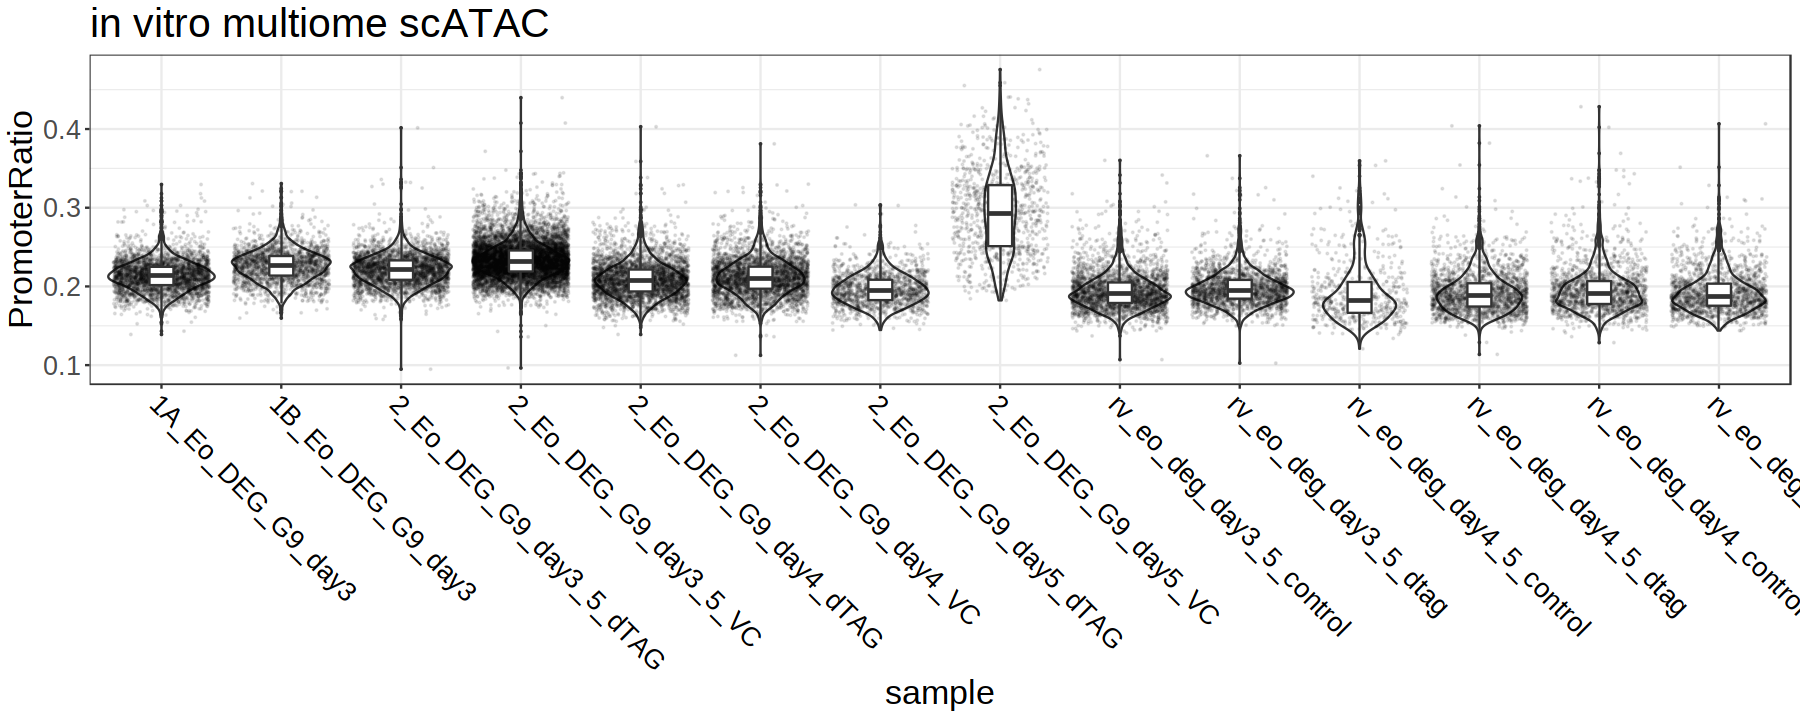

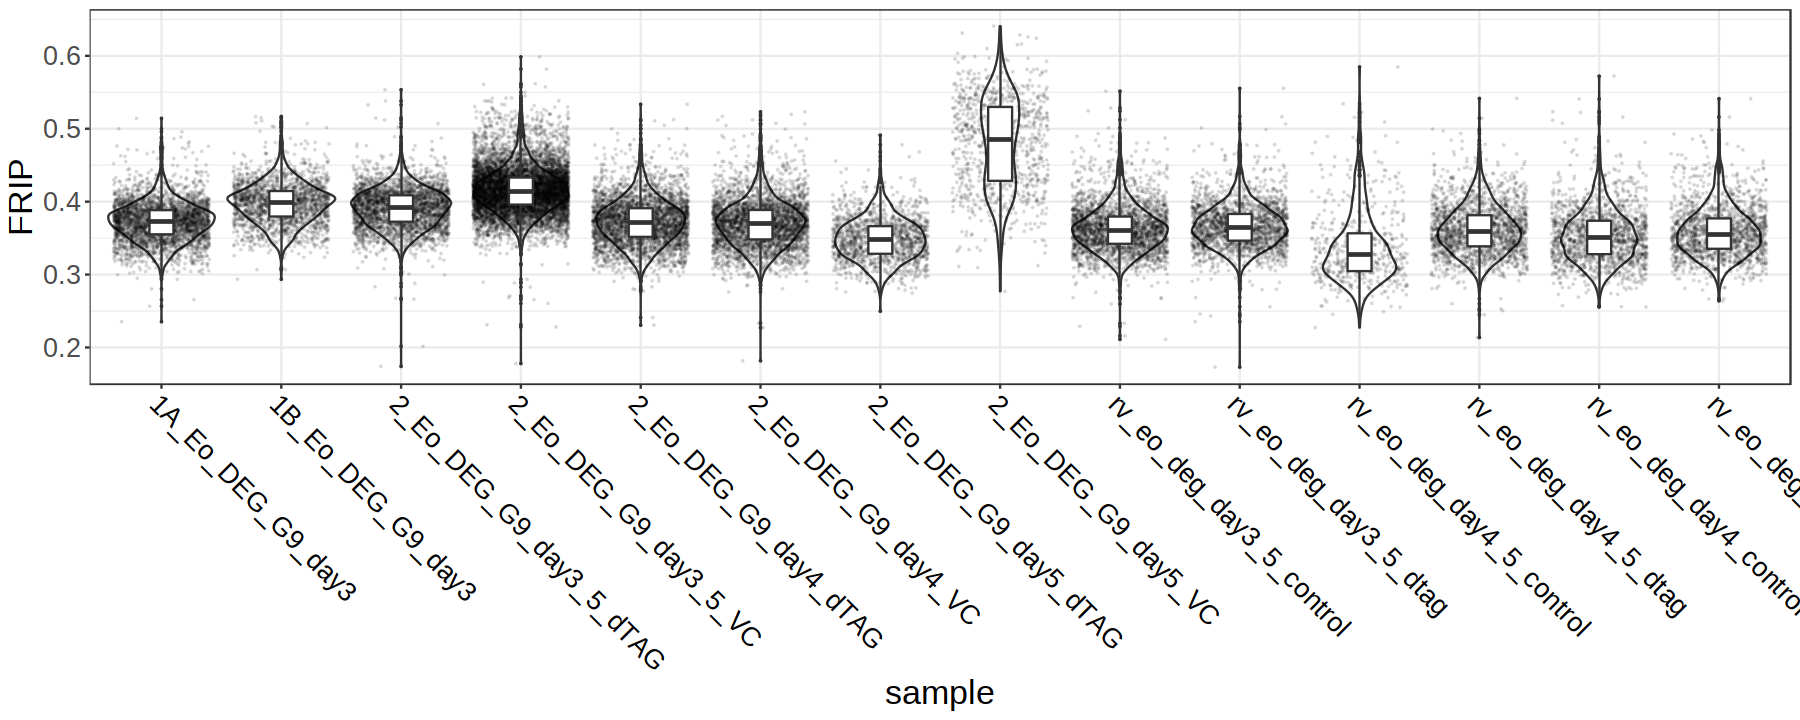

In [20]:
options(repr.plot.width=15, repr.plot.height=6)

ggplot(sample_metadata, aes(sample, PromoterRatio)) + 
    geom_violin() + 
    geom_point(position=position_jitter(width=0.4), size=0.1, alpha=0.1) + 
    geom_boxplot(width = 0.2, outlier.size=0) + 
    ggtitle('in vitro multiome scATAC') + 
    theme_bw() + 
    theme(text=element_text(size=20, color='black'), 
          axis.text.x=element_text(angle=-45, hjust=0, vjust=1, color='black'))

ggplot(sample_metadata, aes(sample, FRIP)) + 
    geom_violin() + 
    geom_point(position=position_jitter(width=0.4), size=0.1, alpha=0.1) + 
    geom_boxplot(width = 0.2, outlier.size=0) + 
    theme_bw() +
    theme(text=element_text(size=20, color='black'), 
          axis.text.x=element_text(angle=-45, hjust=0, vjust=1, color='black'))


In [ ]:
io$archR.peakMatrix.se

In [25]:
peak.mtx = readRDS('/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/processed/atac/archR/Matrices/PeakMatrix_summarized_experiment.rds')

In [26]:
peak.mtx@assays@data$PeakMatrix

class: RangedSummarizedExperiment 
dim: 104278 38757 
metadata(0):
assays(1): PeakMatrix
rownames(104278): chr1:3003397-3003997 chr1:3191569-3192169 ...
  chrX:169880292-169880892 chrX:169883758-169884358
rowData names(1): idx
colnames(38757): 2_Eo_DEG_G9_day3_5_VC#ATAAGCCTCTTAGGGT-1
  2_Eo_DEG_G9_day3_5_VC#CGTTTGGAGGTCCGTA-1 ...
  2_Eo_DEG_G9_day5_VC#CTCCCTGAGGTGAAAT-1
  2_Eo_DEG_G9_day5_VC#CGCTCCATCATCCTGC-1
colData names(38): BlacklistRatio nDiFrags ... ReadsInPeaks FRIP

In [33]:
reads_in_peaks = data.table(cell=colnames(peak.mtx), ReadsInPeaks=colSums(peak.mtx@assays@data$PeakMatrix))

In [37]:
reads_in_peaks = reads_in_peaks[match(meta$cell, reads_in_peaks$cell)]

In [38]:
meta2 = cbind(meta, reads_in_peaks[,2])

In [40]:
meta2 = meta2[,FRIP:=ReadsInPeaks/nFrags_atac]

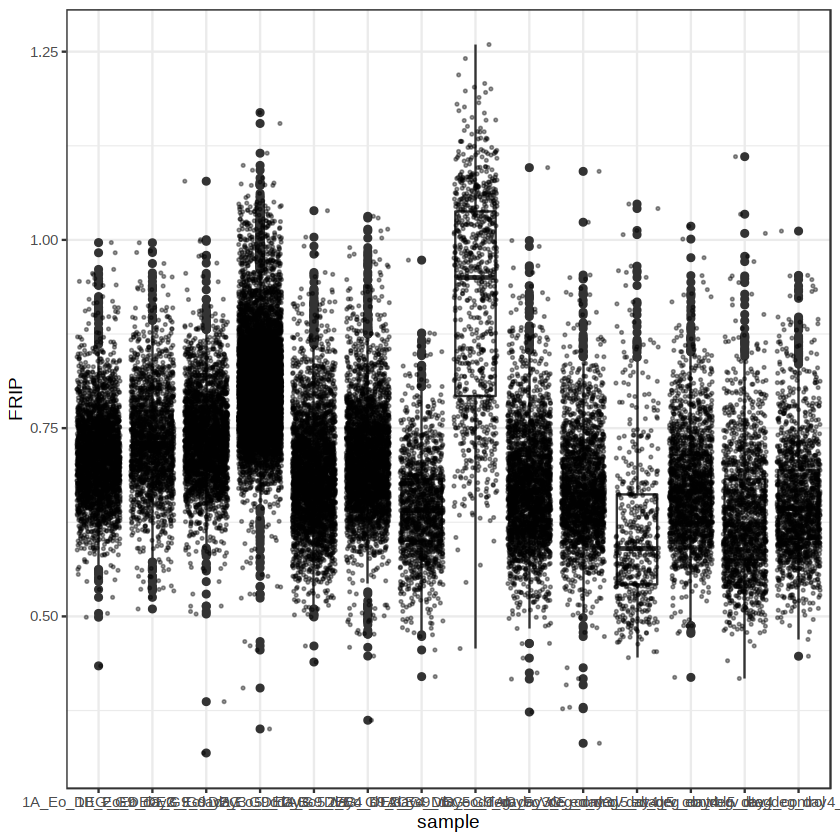

In [42]:
ggplot(meta2, aes(sample, FRIP)) + 
    geom_boxplot() + 
    geom_point(position=position_jitter(width=0.4), size=0.4, alpha=0.4) + 
    theme_bw()

In [22]:
tile.mtx =getMatrixFromProject(
  ArchRProj = ArchRProject,
  useMatrix = "TileMatrix")

ArchR logging to : ArchRLogs/ArchR-getMatrixFromProject-2864e23defec4-Date-2022-11-18_Time-13-41-32.log
If there is an issue, please report to github with logFile!



ERROR: Error in .getMatFromArrow(ArrowFile = ArrowFile, featureDF = featureDF, : Sparse Matrix in Arrow is Binarized! Set binarize = TRUE to use matrix!


# Clustering TileMatrix trial

In [4]:
# START TEST ##b
args <- list()
args$archr_directory <- file.path(io$basedir,"processed/atac/archR")
args$metadata <- file.path(io$basedir,"results/atac/archR/qc/sample_metadata_after_qc.txt.gz")
# END TEST ##

In [8]:
meta = fread(args$metadat)[pass_atacQC==TRUE & doublet_call==FALSE]

In [29]:
nrow(meta)

[1] 33177

In [32]:
ArchRProject.filt = ArchRProject[meta$cell]

In [33]:
ArchRProject.filt


           ___      .______        ______  __    __  .______      
          /   \     |   _  \      /      ||  |  |  | |   _  \     
         /  ^  \    |  |_)  |    |  ,----'|  |__|  | |  |_)  |    
        /  /_\  \   |      /     |  |     |   __   | |      /     
       /  _____  \  |  |\  \\___ |  `----.|  |  |  | |  |\  \\___.
      /__/     \__\ | _| `._____| \______||__|  |__| | _| `._____|
    



class: ArchRProject 
outputDirectory: /rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/processed/atac/archR 
samples(14): rv_eo_deg_day3_5_control rv_eo_deg_day3_5_dtag ...
  2_Eo_DEG_G9_day5_dTAG 2_Eo_DEG_G9_day5_VC
sampleColData names(1): ArrowFiles
cellColData names(38): Sample TSSEnrichment ... ReadsInPeaks FRIP
numberOfCells(1): 33177
medianTSS(1): 14.119
medianFrags(1): 44481

In [34]:
addArchRThreads(16)

Setting default number of Parallel threads to 16.



In [35]:
getAvailableMatrices(ArchRProject.filt)

[1] "DeviationMatrix_CISBP"  "DeviationMatrix_JASPAR" "GeneScoreMatrix_TSS"   
[4] "GeneScoreMatrix_distal" "PeakMatrix"             "PeakMatrix_atlas"      
[7] "TileMatrix"

In [37]:
ArchRProject.filt <- addIterativeLSI(
    ArchRProj = ArchRProject.filt,
    useMatrix = "TileMatrix", 
    name = "IterativeLSI2", 
    iterations = 4, 
    clusterParams = list( #See Seurat::FindClusters
        resolution = c(0.1, 0.2, 0.4), 
        sampleCells = 10000, 
        n.start = 10
    ), 
    varFeatures = 20000, 
    dimsToUse = 1:30
)

ArchRProject.filt <- addUMAP(
    ArchRProj = ArchRProject.filt, 
    reducedDims = "IterativeLSI2", 
    name = "UMAP", 
    nNeighbors = 30, 
    minDist = 0.5, 
    metric = "cosine"
)

p1 <- plotEmbedding(ArchRProj = ArchRProject.filt, colorBy = "cellColData", name = "sample", embedding = "UMAP")

ArchRProject.filt <- addIterativeLSI(
    ArchRProj = ArchRProject.filt,
    useMatrix = "TileMatrix", 
    name = "IterativeLSI", 
    iterations = 2, 
    clusterParams = list( #See Seurat::FindClusters
        resolution = c(0.2), 
        sampleCells = 10000, 
        n.start = 10
    ), 
    varFeatures = 40000, 
    dimsToUse = 1:30
)

ArchRProject.filt <- addUMAP(
    ArchRProj = ArchRProject.filt, 
    reducedDims = "IterativeLSI", 
    name = "UMAP2", 
    nNeighbors = 30, 
    minDist = 0.5, 
    metric = "cosine"
)

p2 <- plotEmbedding(ArchRProj = ArchRProject.filt, colorBy = "cellColData", name = "sample", embedding = "UMAP2")

Checking Inputs...

ArchR logging to : ArchRLogs/ArchR-addIterativeLSI-2e7e79aa73e2-Date-2023-01-23_Time-13-18-33.log
If there is an issue, please report to github with logFile!

2023-01-23 13:18:36 : Computing Total Across All Features, 0.012 mins elapsed.

2023-01-23 13:18:45 : Computing Top Features, 0.162 mins elapsed.

###########
2023-01-23 13:18:46 : Running LSI (1 of 4) on Top Features, 0.182 mins elapsed.
###########

2023-01-23 13:18:46 : Sampling Cells (N = 10008) for Estimated LSI, 0.184 mins elapsed.

2023-01-23 13:18:46 : Creating Sampled Partial Matrix, 0.184 mins elapsed.

2023-01-23 13:19:12 : Computing Estimated LSI (projectAll = FALSE), 0.605 mins elapsed.

Filtering 2 dims correlated > 0.75 to log10(depth + 1)

2023-01-23 13:20:57 : Identifying Clusters, 2.361 mins elapsed.

2023-01-23 13:21:10 : Identified 3 Clusters, 2.571 mins elapsed.

2023-01-23 13:21:10 : Saving LSI Iteration, 2.571 mins elapsed.

2023-01-23 13:21:24 : Creating Cluster Matrix on the total Grou

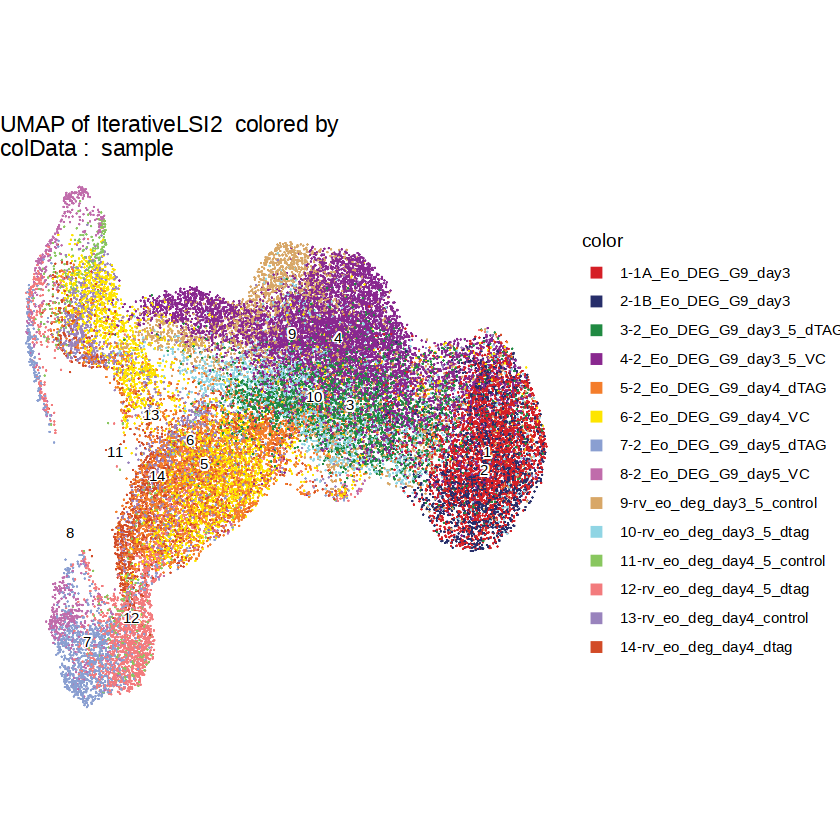

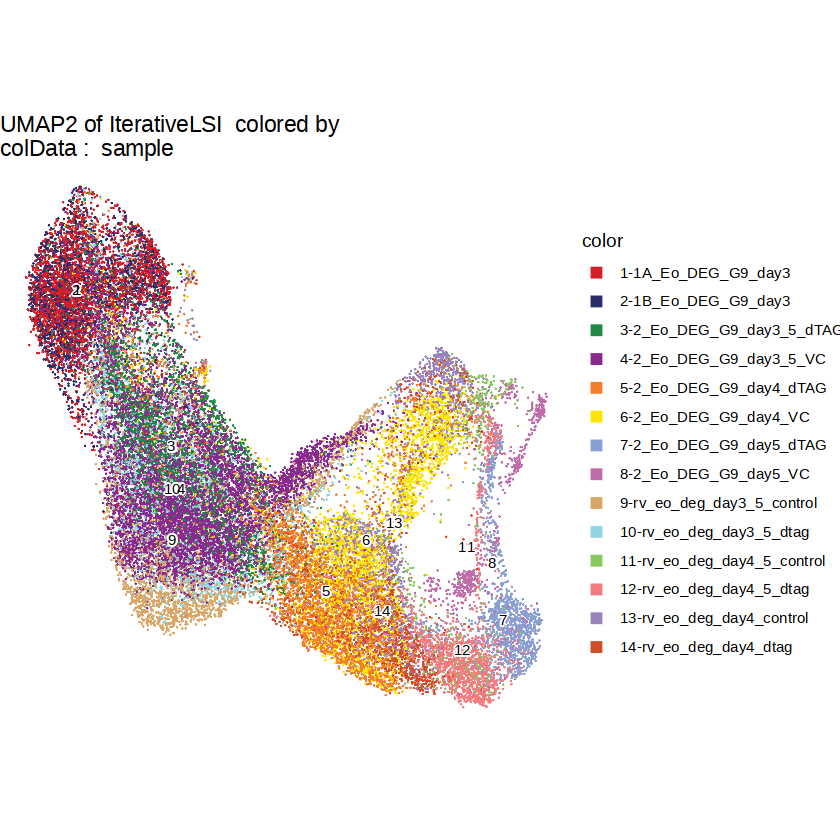

In [38]:
p1 + theme_void()

p2 + theme_void()

Checking Inputs...

ArchR logging to : ArchRLogs/ArchR-addIterativeLSI-2e7e3c1e80f1-Date-2023-01-23_Time-13-33-24.log
If there is an issue, please report to github with logFile!

2023-01-23 13:33:27 : Computing Total Across All Features, 0.01 mins elapsed.

2023-01-23 13:33:31 : Computing Top Features, 0.071 mins elapsed.

###########
2023-01-23 13:33:32 : Running LSI (1 of 4) on Top Features, 0.089 mins elapsed.
###########

2023-01-23 13:33:32 : Sampling Cells (N = 10008) for Estimated LSI, 0.091 mins elapsed.

2023-01-23 13:33:32 : Creating Sampled Partial Matrix, 0.091 mins elapsed.

2023-01-23 13:33:53 : Computing Estimated LSI (projectAll = FALSE), 0.437 mins elapsed.

Filtering 1 dims correlated > 0.75 to log10(depth + 1)

2023-01-23 13:35:07 : Identifying Clusters, 1.676 mins elapsed.

2023-01-23 13:35:18 : Identified 8 Clusters, 1.856 mins elapsed.

2023-01-23 13:35:18 : Saving LSI Iteration, 1.857 mins elapsed.

2023-01-23 13:35:32 : Creating Cluster Matrix on the total Group

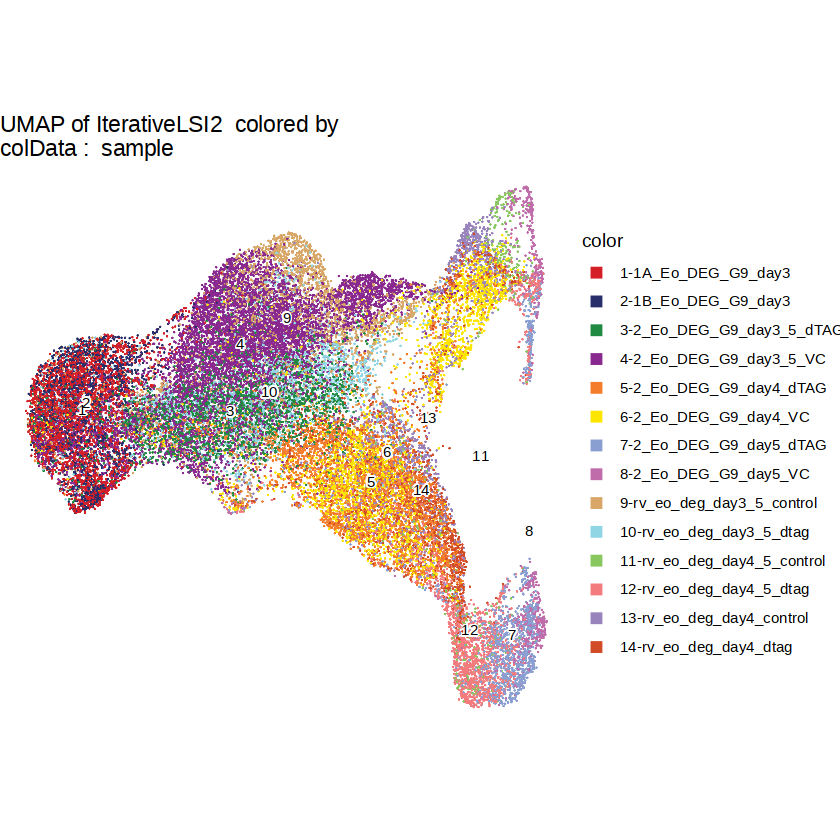

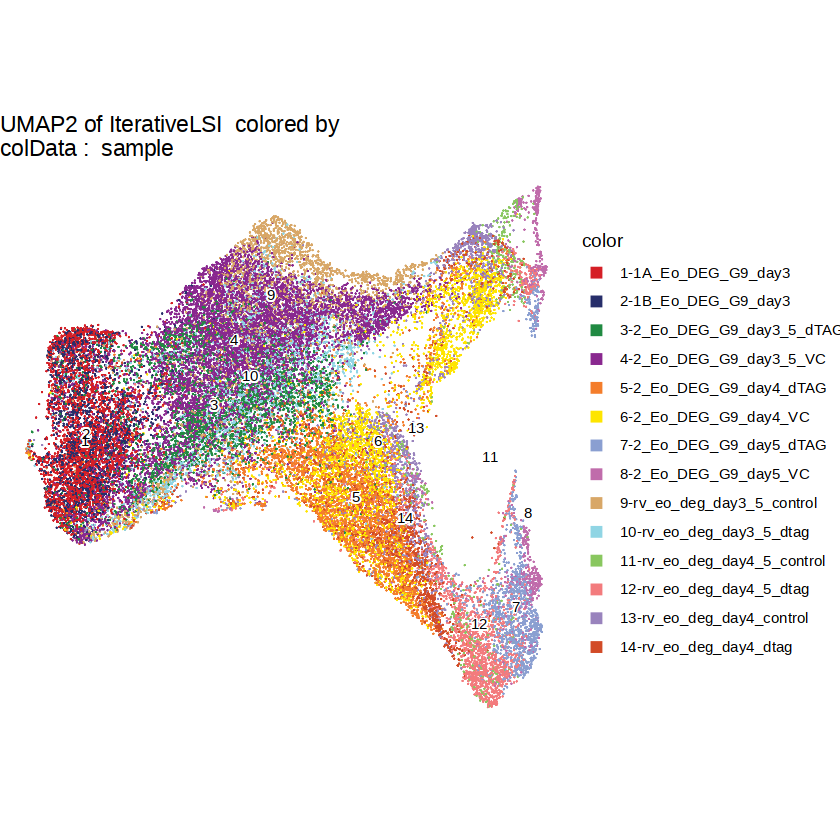

In [39]:
ArchRProject.filt <- addIterativeLSI(
    ArchRProj = ArchRProject.filt,
    useMatrix = "TileMatrix", 
    name = "IterativeLSI2", 
    iterations = 4, 
    clusterParams = list( #See Seurat::FindClusters
        resolution = c(0.4, 1, 2), 
        sampleCells = 10000, 
    maxClusters=NULL, 
        n.start = 10
    ), 
    varFeatures = 20000, 
    dimsToUse = 1:20, 
    force = TRUE
)

ArchRProject.filt <- addUMAP(
    ArchRProj = ArchRProject.filt, 
    reducedDims = "IterativeLSI2", 
    name = "UMAP", 
    nNeighbors = 25, 
    minDist = 0.3, 
    metric = "cosine",
    force = TRUE
)

p1 <- plotEmbedding(ArchRProj = ArchRProject.filt, colorBy = "cellColData", name = "sample", embedding = "UMAP")

ArchRProject.filt <- addIterativeLSI(
    ArchRProj = ArchRProject.filt,
    useMatrix = "TileMatrix", 
    name = "IterativeLSI", 
    iterations = 2, 
    clusterParams = list( #See Seurat::FindClusters
        resolution = c(2), 
        sampleCells = 10000, 
    maxClusters=NULL, 
        n.start = 10
    ), 
    varFeatures = 40000, 
    dimsToUse = 1:20,
    force = TRUE
)

ArchRProject.filt <- addUMAP(
    ArchRProj = ArchRProject.filt, 
    reducedDims = "IterativeLSI", 
    name = "UMAP2", 
    nNeighbors = 25, 
    minDist = 0.3, 
    metric = "cosine",
    force = TRUE
)

p2 <- plotEmbedding(ArchRProj = ArchRProject.filt, colorBy = "cellColData", name = "sample", embedding = "UMAP2")

p1 + theme_void()

p2 + theme_void()

In [ ]:
ArchRProject.filt <- addIterativeLSI(
    ArchRProj = ArchRProject.filt,
    useMatrix = "TileMatrix", 
    name = "IterativeLSI2", 
    iterations = 4, 
    clusterParams = list( #See Seurat::FindClusters
        resolution = c(0.4, 1, 2), 
        sampleCells = 10000, 
    maxClusters=NULL, 
        n.start = 10
    ), 
    varFeatures = 30000, 
    dimsToUse = 1:20, 
    force = TRUE
)

ArchRProject.filt <- addUMAP(
    ArchRProj = ArchRProject.filt, 
    reducedDims = "IterativeLSI2", 
    name = "UMAP", 
    nNeighbors = 25, 
    minDist = 0.3, 
    metric = "cosine",
    force = TRUE
)

p1 <- plotEmbedding(ArchRProj = ArchRProject.filt, colorBy = "cellColData", name = "sample", embedding = "UMAP")

ArchRProject.filt <- addIterativeLSI(
    ArchRProj = ArchRProject.filt,
    useMatrix = "TileMatrix", 
    name = "IterativeLSI", 
    iterations = 2, 
    clusterParams = list( #See Seurat::FindClusters
        resolution = c(2), 
        sampleCells = 10000, 
    maxClusters=NULL, 
        n.start = 10
    ), 
    varFeatures = 60000, 
    dimsToUse = 1:20,
    force = TRUE
)

ArchRProject.filt <- addUMAP(
    ArchRProj = ArchRProject.filt, 
    reducedDims = "IterativeLSI", 
    name = "UMAP2", 
    nNeighbors = 25, 
    minDist = 0.3, 
    metric = "cosine",
    force = TRUE
)

p2 <- plotEmbedding(ArchRProj = ArchRProject.filt, colorBy = "cellColData", name = "sample", embedding = "UMAP2")

p1 + theme_void()

p2 + theme_void()

Checking Inputs...

ArchR logging to : ArchRLogs/ArchR-addIterativeLSI-2e7e75c775a4-Date-2023-01-23_Time-13-46-34.log
If there is an issue, please report to github with logFile!

2023-01-23 13:46:37 : Computing Total Across All Features, 0.009 mins elapsed.

2023-01-23 13:46:40 : Computing Top Features, 0.071 mins elapsed.

###########
2023-01-23 13:46:42 : Running LSI (1 of 4) on Top Features, 0.089 mins elapsed.
###########

2023-01-23 13:46:42 : Sampling Cells (N = 10008) for Estimated LSI, 0.09 mins elapsed.

2023-01-23 13:46:42 : Creating Sampled Partial Matrix, 0.09 mins elapsed.

2023-01-23 13:47:05 : Computing Estimated LSI (projectAll = FALSE), 0.475 mins elapsed.

Filtering 1 dims correlated > 0.75 to log10(depth + 1)

2023-01-23 13:47:49 : Identifying Clusters, 1.207 mins elapsed.

2023-01-23 13:48:00 : Identified 8 Clusters, 1.394 mins elapsed.

2023-01-23 13:48:00 : Saving LSI Iteration, 1.394 mins elapsed.

2023-01-23 13:48:14 : Creating Cluster Matrix on the total Group 

In [ ]:
ArchRProject.filt <- addIterativeLSI(
    ArchRProj = ArchRProject.filt,
    useMatrix = "PeakMatrix", 
    name = "IterativeLSI2", 
    iterations = 4, 
    clusterParams = list( #See Seurat::FindClusters
        resolution = c(0.4, 1, 2), 
        sampleCells = 10000, 
    maxClusters=NULL, 
        n.start = 10
    ), 
    varFeatures = 20000, 
    dimsToUse = 1:20, 
    force = TRUE
)

ArchRProject.filt <- addUMAP(
    ArchRProj = ArchRProject.filt, 
    reducedDims = "IterativeLSI2", 
    name = "UMAP", 
    nNeighbors = 25, 
    minDist = 0.3, 
    metric = "cosine",
    force = TRUE
)

p1 <- plotEmbedding(ArchRProj = ArchRProject.filt, colorBy = "cellColData", name = "sample", embedding = "UMAP")

ArchRProject.filt <- addIterativeLSI(
    ArchRProj = ArchRProject.filt,
    useMatrix = "PeakMatrix", 
    name = "IterativeLSI", 
    iterations = 2, 
    clusterParams = list( #See Seurat::FindClusters
        resolution = c(2), 
        sampleCells = 10000, 
    maxClusters=NULL, 
        n.start = 10
    ), 
    varFeatures = 40000, 
    dimsToUse = 1:20,
    force = TRUE
)

ArchRProject.filt <- addUMAP(
    ArchRProj = ArchRProject.filt, 
    reducedDims = "IterativeLSI", 
    name = "UMAP2", 
    nNeighbors = 25, 
    minDist = 0.3, 
    metric = "cosine",
    force = TRUE
)

p2 <- plotEmbedding(ArchRProj = ArchRProject.filt, colorBy = "cellColData", name = "sample", embedding = "UMAP2")

p1 + theme_void()

p2 + theme_void()

In [ ]:
ArchRProject.filt <- addIterativeLSI(
  ArchRProj = ArchRProject.filt,
  useMatrix = 'PeakMatrix', 
  name = "IterativeLSI", 
  firstSelection = "Top",
  depthCol = "nFrags",
  iterations = 2, 
   clusterParams = list(
    resolution = 2, 
    sampleCells = 10000, 
    maxClusters=NULL,
    n.start = 10
   ), 
  saveIterations = FALSE,
  varFeatures = 25000, 
  dimsToUse = 1:25,
  force = TRUE
)

ArchRProject.filt <- addUMAP(
    ArchRProj = ArchRProject.filt, 
    reducedDims = "IterativeLSI2", 
    name = "UMAP", 
    nNeighbors = 25, 
    minDist = 0.3, 
    metric = "cosine",
    force = TRUE
)
 plotEmbedding(ArchRProj = ArchRProject.filt, colorBy = "cellColData", name = "sample", embedding = "UMAP2") + theme_void()

In [ ]:
ArchRProject.filt@cellColData$celltype

In [ ]:
 plotEmbedding(ArchRProj = ArchRProject.filt, colorBy = "cellColData", name = "celltype", embedding = "UMAP2") + theme_void()

# Test clustering on LSI imported from previous code